In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("/kaggle/input/datasets/leonardopena/top50spotify2019/top50.csv", encoding = "Latin-1")

In [4]:
df.head()

,Unnamed: 0,Track.Name,Artist.Name,Genre,Beats.Per.Minute,Energy,Danceability,Loudness..dB..,Liveness,Valence.,Length.,Acousticness..,Speechiness.,Popularity
0,1,Señorita,Shawn Mendes,canadian pop,117,55,76,-6,8,75,191,4,3,79
1,2,China,Anuel AA,reggaeton flow,105,81,79,-4,8,61,302,8,9,92
2,3,boyfriend (with Social House),Ariana Grande,dance pop,190,80,40,-4,16,70,186,12,46,85
3,4,Beautiful People (feat. Khalid),Ed Sheeran,pop,93,65,64,-8,8,55,198,12,19,86
4,5,Goodbyes (Feat. Young Thug),Post Malone,dfw rap,150,65,58,-4,11,18,175,45,7,94


In [5]:
df.shape

(50, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        50 non-null     int64 
 1   Track.Name        50 non-null     object
 2   Artist.Name       50 non-null     object
 3   Genre             50 non-null     object
 4   Beats.Per.Minute  50 non-null     int64 
 5   Energy            50 non-null     int64 
 6   Danceability      50 non-null     int64 
 7   Loudness..dB..    50 non-null     int64 
 8   Liveness          50 non-null     int64 
 9   Valence.          50 non-null     int64 
 10  Length.           50 non-null     int64 
 11  Acousticness..    50 non-null     int64 
 12  Speechiness.      50 non-null     int64 
 13  Popularity        50 non-null     int64 
dtypes: int64(11), object(3)
memory usage: 5.6+ KB


In [7]:
df.describe()

,Unnamed: 0,Beats.Per.Minute,Energy,Danceability,Loudness..dB..,Liveness,Valence.,Length.,Acousticness..,Speechiness.,Popularity
count,50.00000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,120.060000,64.060000,71.38000,-5.660000,14.660000,54.600000,200.960000,22.160000,12.480000,87.500000
std,14.57738,30.898392,14.231913,11.92988,2.056448,11.118306,22.336024,39.143879,18.995553,11.161596,4.491489
min,1.00000,85.000000,32.000000,29.00000,-11.000000,5.000000,10.000000,115.000000,1.000000,3.000000,70.000000
25%,13.25000,96.000000,55.250000,67.00000,-6.750000,8.000000,38.250000,176.750000,8.250000,5.000000,86.000000
50%,25.50000,104.500000,66.500000,73.50000,-6.000000,11.000000,55.500000,198.000000,15.000000,7.000000,88.000000
75%,37.75000,137.500000,74.750000,79.75000,-4.000000,15.750000,69.500000,217.500000,33.750000,15.000000,90.750000
max,50.00000,190.000000,88.000000,90.00000,-2.000000,58.000000,95.000000,309.000000,75.000000,46.000000,95.000000


In [8]:
df.isnull().sum()

Unnamed: 0          0
Track.Name          0
Artist.Name         0
Genre               0
Beats.Per.Minute    0
Energy              0
Danceability        0
Loudness..dB..      0
Liveness            0
Valence.            0
Length.             0
Acousticness..      0
Speechiness.        0
Popularity          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop(columns='Unnamed: 0')

In [11]:
df = df.rename(columns={
    'Track.Name': 'Track',
    'Artist.Name': 'Artist',
    'Beats.Per.Minute': 'BPM',
    'Loudness..dB..': 'Loudness_dB',
    'Valence.': 'Valence',
    'Length.': 'Length',
    'Acousticness..': 'Acousticness',
    'Speechiness.': 'Speechiness'
})

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Track         50 non-null     object
 1   Artist        50 non-null     object
 2   Genre         50 non-null     object
 3   BPM           50 non-null     int64 
 4   Energy        50 non-null     int64 
 5   Danceability  50 non-null     int64 
 6   Loudness_dB   50 non-null     int64 
 7   Liveness      50 non-null     int64 
 8   Valence       50 non-null     int64 
 9   Length        50 non-null     int64 
 10  Acousticness  50 non-null     int64 
 11  Speechiness   50 non-null     int64 
 12  Popularity    50 non-null     int64 
dtypes: int64(10), object(3)
memory usage: 5.2+ KB


### Cleaning Summary

- No missing values were found.
- No duplicate rows were found.
- The unnecessary `Unnamed: 0` index column was removed.
- Column names were cleaned and standardized for easier analysis.
- No rows were removed from the dataset.

## Top Artists in the Top 50

We examine which artists have the highest number of songs in the Top 50 dataset.

In [13]:
artist_counts = (df['Artist'].value_counts().reset_index())

artist_counts.columns = ['Artist', 'Number of Songs']

fig = px.bar(
    artist_counts.head(10),
    x = 'Artist',
    y = 'Number of Songs',
    text = 'Number of Songs',
    title = 'Top Artists by Number of Songs',
    labels = {
        'Artist': 'Artist',
        'Number of Songs': 'Number of Songs'
    }
)

fig.update_traces(
    textposition = 'outside'
)

fig.update_layout(
    title_x = 0.5
)

fig.show()

### Insight

Ed Sheeran has the highest representation in the Top 50, with 4 songs, while the other leading artists each have 2 songs. 
This indicates that Ed Sheeran has a stronger presence in this particular Top 50 sample, although the number of songs does not directly represent overall artist popularity.

## Top Genres in the Top 50

We examine the distribution of music genres to identify which genres are most represented in the Top 50.

In [14]:
genre_counts = (df['Genre'].value_counts().reset_index())

genre_counts.columns = ['Genre', 'Number of Songs']

fig = px.bar(
    genre_counts,
    x = 'Genre',
    y = 'Number of Songs',
    text = 'Number of Songs',
    title = 'Genre Distribution in the Top 50',
    labels = {
        'Genre': 'Genre',
        'Number of Songs': 'Number of Songs'
    }
)

fig.update_traces(
    textposition = 'outside'
)

fig.update_layout(
    title_x = 0.5,
    xaxis_tickangle = -45
)

fig.show()

### Insight

Dance pop is the most represented genre in the Top 50 dataset, with 8 songs, followed by pop with 7 songs and latin with 5 songs. 
Together, these three genres account for 40% of the songs in the dataset, while the remaining songs are distributed across a wide range of genres.

## Popularity Distribution

We examine how popularity scores are distributed across the Top 50 songs.

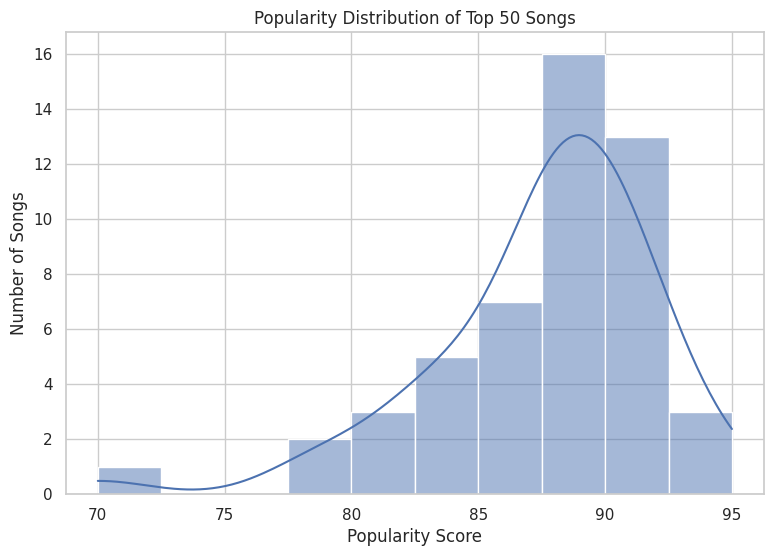

In [15]:
plt.figure(figsize = (9, 6))

sns.histplot(
    data = df,
    x = 'Popularity',
    bins = 10,
    kde = True
)

plt.title('Popularity Distribution of Top 50 Songs')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Songs')

plt.show()

### Insight

Popularity scores are concentrated at the higher end of the scale, with most songs scoring between 87 and 93. 
Only a small number of songs have noticeably lower popularity scores, while the overall distribution reflects the highly popular nature of the Top 50 dataset.

## Popularity vs Danceability

We examine the relationship between song popularity and danceability to see whether more danceable songs tend to have higher popularity scores.

In [16]:
fig = px.scatter(
    df,
    x = 'Danceability',
    y = 'Popularity',
    hover_name = 'Track',
    hover_data = ['Artist', 'Genre'],
    trendline = 'ols',
    title = 'Popularity vs Danceability',
    labels = {
        'Danceability': 'Danceability',
        'Popularity': 'Popularity Score'
    }
)

fig.update_layout(
    title_x = 0.5
)

fig.show()

### Insight

The relationship between danceability and popularity appears to be very weak in this dataset. 
The trendline shows a slight negative direction, but the data points are widely scattered, indicating that higher danceability does not necessarily correspond to higher popularity among the Top 50 songs.

## Popularity vs Energy

We examine the relationship between song energy and popularity to determine whether more energetic songs tend to have higher popularity scores.

In [17]:
fig = px.scatter(
    df,
    x = 'Energy',
    y = 'Popularity',
    hover_name = 'Track',
    hover_data = ['Artist', 'Genre'],
    trendline = 'ols',
    title = 'Popularity vs Energy',
    labels = {
        'Energy': 'Energy',
        'Popularity': 'Popularity Score'
    }
)

fig.update_layout(
    title_x = 0.5
)

fig.show()

### Insight

Energy shows a very weak negative relationship with popularity in the Top 50 dataset.
The wide spread of popularity scores across different energy levels suggests that energy alone does not strongly determine a song's popularity.

## Popularity vs Valence

We examine the relationship between valence and popularity to determine whether songs with a more positive musical character tend to have higher popularity scores.

In [18]:
fig = px.scatter(
    df,
    x = 'Valence',
    y = 'Popularity',
    hover_name = 'Track',
    hover_data = ['Artist', 'Genre'],
    trendline = 'ols',
    title = 'Popularity vs Valence',
    labels = {
        'Valence': 'Valence',
        'Popularity': 'Popularity Score'
    }
)

fig.update_layout(
    title_x = 0.5
)

fig.show()

### Insight

Valence shows a weak negative relationship with popularity in the Top 50 dataset.
Although the trendline suggests that popularity tends to decrease slightly as valence increases, the wide spread of data points indicates that valence alone is not a strong driver of song popularity.

## Average Popularity by Genre

We compare the average popularity of songs across genres to identify which genres have higher popularity scores within the Top 50 dataset.

In [19]:
genre_popularity = (
    df.groupby('Genre')
      .agg(
          Avg_Popularity =('Popularity', 'mean'),
          Song_Count = ('Popularity', 'count')
      )
      .query('Song_Count >= 2')
      .sort_values('Avg_Popularity', ascending = False)
      .reset_index()
)

fig = px.bar(
    genre_popularity,
    x = 'Genre',
    y = 'Avg_Popularity',
    text = genre_popularity['Avg_Popularity'].round(1),
    title = 'Average Popularity by Genre',
    labels = {
        'Genre': 'Genre',
        'Avg_Popularity': 'Average Popularity'
    },
    hover_data = ['Song_Count']
)

fig.update_traces(
    textposition = 'outside'
)

fig.update_layout(
    title_x = 0.5,
    xaxis_tickangle = -45
)

fig.show()

### Insight

DFW rap has the highest average popularity score at 92.5, followed by electropop at 92.0 and reggaeton at 91.0. 
Most genres show relatively high average popularity scores, while Canadian pop has the lowest average at 74.5 among the displayed genres. 
These results reflect the songs included in this Top 50 sample and should not be interpreted as overall genre popularity.

## Average Audio Features

We compare the average audio characteristics of the Top 50 songs to understand their overall musical profile.

In [20]:
audio_features = [
    'Energy',
    'Danceability',
    'Valence',
    'Acousticness',
    'Speechiness',
    'Liveness'
]

feature_means = (
    df[audio_features]
    .mean()
    .sort_values(ascending = False)
    .reset_index()
)

feature_means.columns = ['Feature', 'Average Value']

fig = px.bar(
    feature_means,
    x = 'Feature',
    y = 'Average Value',
    text = feature_means['Average Value'].round(1),
    title = 'Average Audio Features of Top 50 Songs',
    labels = {
        'Feature': 'Audio Feature',
        'Average Value': 'Average Value'
    }
)

fig.update_traces(
    textposition = 'outside'
)

fig.update_layout(
    title_x = 0.5
)

fig.show()

### Insight

The Top 50 songs show a generally danceable and energetic musical profile, with average danceability of 71.4 and energy of 64.1. 
Valence has a moderate average of 54.6, while acousticness, liveness, and speechiness are considerably lower, indicating that the songs are generally more dance-oriented and energetic than acoustic or speech-focused.

## BPM Distribution

We examine the distribution of beats per minute (BPM) to understand the typical tempo range of the Top 50 songs.

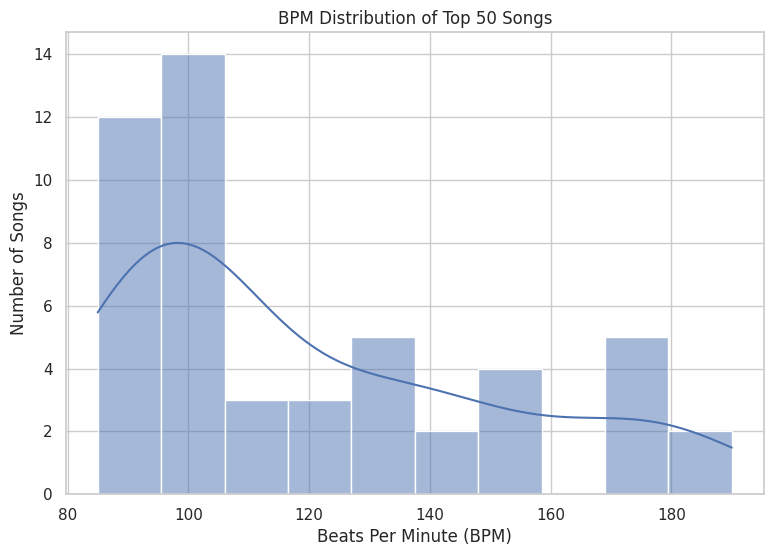

In [21]:
plt.figure(figsize = (9, 6))

sns.histplot(
    data = df,
    x = 'BPM',
    bins = 10,
    kde = True
)

plt.title('BPM Distribution of Top 50 Songs')
plt.xlabel('Beats Per Minute (BPM)')
plt.ylabel('Number of Songs')

plt.show()

### Insight

Most songs in the Top 50 dataset are concentrated around the 85–105 BPM range.
The distribution is right-skewed, with fewer songs having higher tempos extending up to around 190 BPM.
Although the average tempo is approximately 120 BPM, the histogram shows that the majority of songs are concentrated at lower BPM values.

## Song Length Distribution

We examine the distribution of song lengths to understand the typical duration of tracks in the Top 50 dataset.

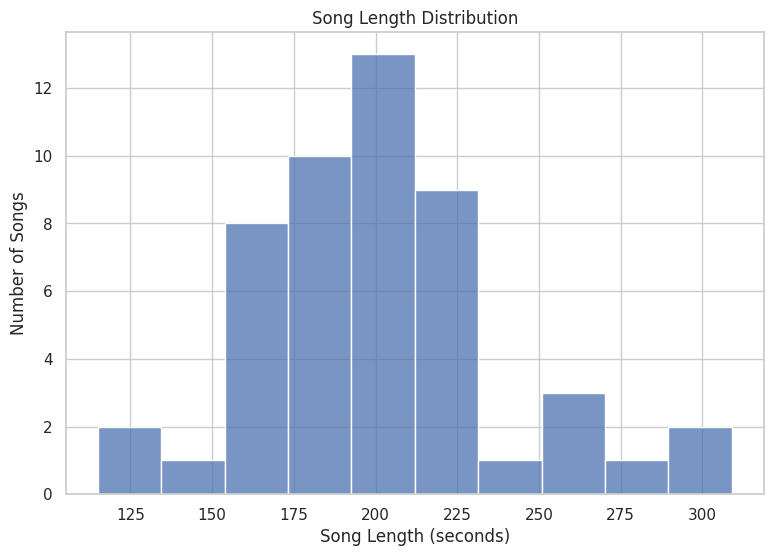

In [22]:
plt.figure(figsize = (9, 6))

sns.histplot(
    data = df,
    x = 'Length',
    bins = 10
)

plt.title('Song Length Distribution')
plt.xlabel('Song Length (seconds)')
plt.ylabel('Number of Songs')

plt.show()

### Insight

Most songs in the Top 50 dataset are concentrated between approximately 160 and 230 seconds, with the highest concentration around 195–210 seconds. 
This indicates that songs in the dataset generally have a duration of around 3 to 3.5 minutes, while very short and very long tracks are less common.

## Average Popularity by Artist

We compare the average popularity scores of artists with multiple songs in the Top 50 dataset.

In [23]:
artist_popularity = (
    df.groupby('Artist')
      .agg(
          Avg_Popularity = ('Popularity', 'mean'),
          Song_Count = ('Popularity', 'count')
      )
      .query('Song_Count >= 2')
      .sort_values('Avg_Popularity', ascending = False)
      .reset_index()
)

fig = px.bar(
    artist_popularity,
    x = 'Artist',
    y = 'Avg_Popularity',
    text = artist_popularity['Avg_Popularity'].round(1),
    title = 'Average Popularity by Artist',
    labels = {
        'Artist': 'Artist',
        'Avg_Popularity': 'Average Popularity'
    },
    hover_data = ['Song_Count']
)

fig.update_traces(
    textposition = 'outside'
)

fig.update_layout(
    title_x = 0.5,
    xaxis_tickangle = -45
)

fig.show()

### Insight

Post Malone has the highest average popularity score among artists with multiple songs in the dataset, at 92.5, followed by Billie Eilish at 92.0. 
Interestingly, Ed Sheeran, who has the highest number of songs in the Top 50, has a lower average popularity score of 84.8, showing that having more songs in the list does not necessarily mean having the highest average popularity.

## Feature Correlation Analysis

We examine the correlations between the main numerical features to identify relationships and understand which audio characteristics are most associated with popularity.

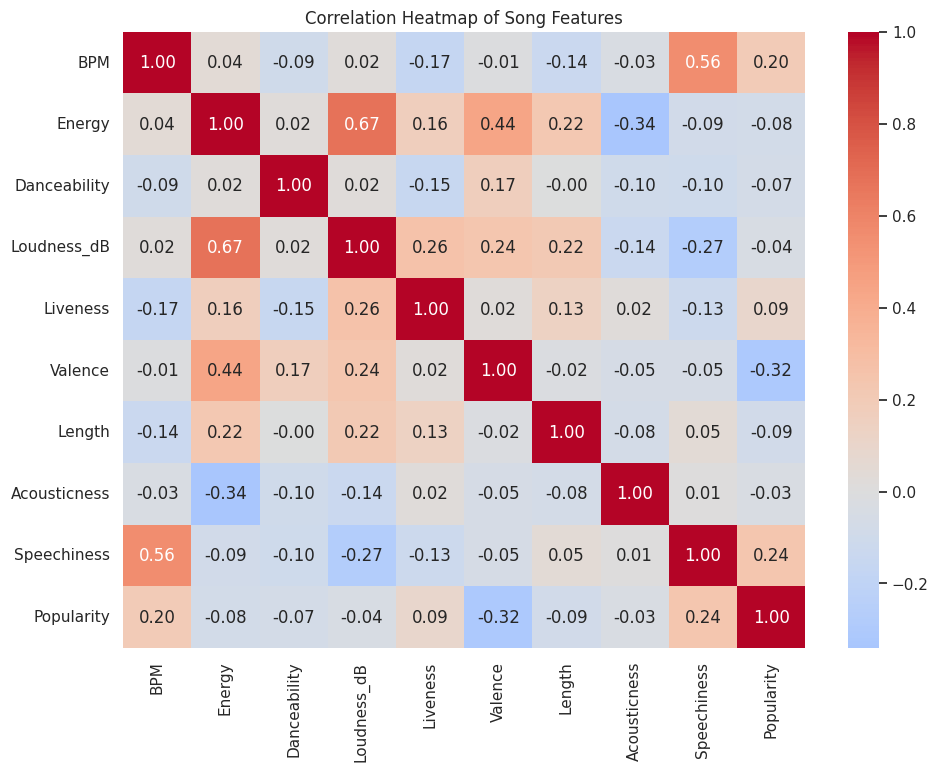

In [24]:
corr = df.select_dtypes(include = 'number').corr()

plt.figure(figsize = (11, 8))

sns.heatmap(
    corr,
    annot = True,
    fmt = '.2f',
    cmap = 'coolwarm',
    center = 0
)

plt.title('Correlation Heatmap of Song Features')
plt.show()

### Insight

Valence has the strongest correlation with popularity among the audio features, with a moderate negative correlation of -0.32. 
Speechiness and BPM show weak positive correlations with popularity, while energy and danceability have very weak relationships with popularity.
Overall, no single audio feature shows a strong linear relationship with popularity in this dataset.

## Top 10 Most Popular Songs

We identify the 10 most popular songs in the dataset based on their popularity scores.

In [25]:
top_10 = df.nlargest(10, 'Popularity').sort_values('Popularity')

fig = px.bar(
    top_10,
    x = 'Popularity',
    y = 'Track',
    orientation = 'h',
    text = 'Popularity',
    hover_data = ['Artist', 'Genre'],
    title = 'Top 10 Most Popular Songs',
    labels = {
        'Popularity': 'Popularity Score',
        'Track': 'Song'
    }
)

fig.update_traces(
    textposition = 'outside'
)

fig.update_layout(
    title_x = 0.5
)

fig.show()

### Insight

Bad Guy ranks as the most popular song in the dataset with a popularity score of 95, followed by Goodbyes at 94 and Callaita at 93. 
The remaining songs in the Top 10 score between 91 and 92, showing that the most popular tracks have relatively close popularity scores.

# Final Key Insights

- Ed Sheeran has the highest representation in the Top 50 dataset with 4 songs, while several other leading artists have 2 songs each.
- Dance pop is the most represented genre with 8 songs, followed by pop with 7 and latin with 5.
- Popularity scores are concentrated at the higher end of the scale, with most songs scoring between 87 and 93.
- The Top 50 songs generally have a danceable and energetic musical profile, with average danceability of 71.4 and energy of 64.1.
- Most songs have a tempo concentrated around 85–105 BPM and a duration mainly between 160 and 230 seconds.
- No single audio feature shows a strong linear relationship with popularity. Valence has the strongest correlation with popularity at -0.32.
- Post Malone has the highest average popularity among artists with multiple songs, while Ed Sheeran's larger representation does not translate into the highest average popularity.
- "bad guy" has the highest popularity score in the dataset at 95.

# Conclusion

This exploratory analysis examined the characteristics of 50 highly popular songs, including artist representation, genre distribution, popularity, audio features, tempo, and song length.

The analysis shows that the dataset is dominated by highly popular tracks with generally high danceability and energy. However, the relationships between individual audio features and popularity are relatively weak, suggesting that popularity cannot be explained by a single musical characteristic.

Overall, the analysis provides a clear overview of the musical characteristics and patterns present within the Top 50 dataset.